# Sentiment Analysis of Movie Reviews  
**NLP Project course – DLBAIPNLP01**  
**Rusingiza Nshuti Braille**  
Matriculation Number: 4243333  
Date: 06.05.2026

## 1. Import libraries  
We first need to import All necessary packages for data handling, preprocessing, classical models, DistilBERT and a simple neural network were imported.

In [ ]:
# ================================================
# INSTALL + IMPORT LIBRARIES
# ================================================


!pip install transformers datasets wordcloud --quiet

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from wordcloud import WordCloud

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import LabelEncoder

import torch
from transformers import pipeline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ================================================
# NLTK SETUP
# ================================================

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

stop_words = set(stopwords.words("english"))

# We need to Keep negation words because they are important for sentiment analysis.
# For Example: "not good" should not become "good".
negation_words = {"not", "no", "nor", "never", "n't"}
stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

print("PyTorch version:", torch.__version__)
print("TensorFlow version:", tf.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU device:", torch.cuda.get_device_name(0))

print("All libraries loaded successfully.")

PyTorch version: 2.11.0+cu128
TensorFlow version: 2.20.0
GPU available: True
GPU device: Tesla T4
All libraries loaded successfully.


In [ ]:
# ================================================
# REPRODUCIBILITY
# ================================================

import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Random seeds fixed for reproducibility.")

Random seeds fixed for reproducibility.


## Reproducibility

Random seeds were fixed to make sure reproducibility of the experimental results across different many runs.

## 2. Load the data  
Secondly, the Stanford Large Movie Review Dataset (25,000 train + 25,000 test) need to be loaded well. and The classes are perfectly balanced.

In [ ]:
# Load the official IMDB dataset (50k balanced movie reviews)
from datasets import load_dataset
dataset = load_dataset("stanfordnlp/imdb")

df_train = pd.DataFrame({
    'review': dataset['train']['text'],
    'sentiment': ['positive' if label == 1 else 'negative' for label in dataset['train']['label']]
})

df_test = pd.DataFrame({
    'review': dataset['test']['text'],
    'sentiment': ['positive' if label == 1 else 'negative' for label in dataset['test']['label']]
})

print(f"Training samples: {len(df_train):,}")
print(f"Test samples: {len(df_test):,}")
print("\nClass distribution:\n", df_train['sentiment'].value_counts())

Training samples: 25,000
Test samples: 25,000

Class distribution:
 sentiment
negative    12500
positive    12500
Name: count, dtype: int64


## 3. Dataset Distribution

The IMDB dataset contains balanced sentiment classes with equal numbers of positive and negative movie reviews.

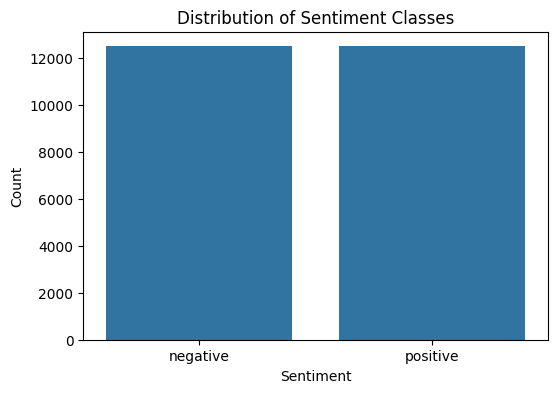

In [ ]:
# ================================================
# DATASET DISTRIBUTION
# ================================================

import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_train,
    x="sentiment"
)

plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

## 4. Preprocessing of the text  
Text was cleaned (lowercased, HTML and special characters removed), stop words were removed and words were lemmatized – exactly as required by the task.

In [ ]:
# ================================================
# TEXT PREPROCESSING
# ================================================

def preprocess(text):
    """
    Clean text for traditional machine learning models.
    Lowercase, remove HTML, remove special characters, remove stop words,
    and lemmatize tokens while keeping important negation words.
    """
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    tokens = text.split()

    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 1
    ]

    return " ".join(cleaned_tokens)


print("Preprocessing training and test sets...")

df_train["clean_review"] = df_train["review"].apply(preprocess)
df_test["clean_review"] = df_test["review"].apply(preprocess)

print("Preprocessing completed successfully.")
print("Example cleaned review:")
print(df_train["clean_review"].iloc[0][:300])

Preprocessing training and test sets...
Preprocessing completed successfully.
Example cleaned review:
rented curious yellow video store controversy surrounded first released also heard first seized custom ever tried enter country therefore fan film considered controversial really see plot centered around young swedish drama student named lena want learn everything life particular want focus attentio


## 5. Progressive subsets  
Subsets of 1,000, 10,000 and the full 25,000 training samples were created to evaluate model performance as dataset size increases (task requirement).

In [ ]:
# Create progressive subsets for evaluation
small_train  = df_train.sample(1000, random_state=42).reset_index(drop=True)
medium_train = df_train.sample(10000, random_state=42).reset_index(drop=True)
full_train   = df_train.copy().reset_index(drop=True)

print(f"Small subset:  {len(small_train):,} reviews")
print(f"Medium subset: {len(medium_train):,} reviews")
print(f"Full dataset:  {len(full_train):,} reviews")

Small subset:  1,000 reviews
Medium subset: 10,000 reviews
Full dataset:  25,000 reviews


## 6. Word clouds  
Word clouds for positive and negative reviews were generated to visually inspect the most frequent terms in each class.

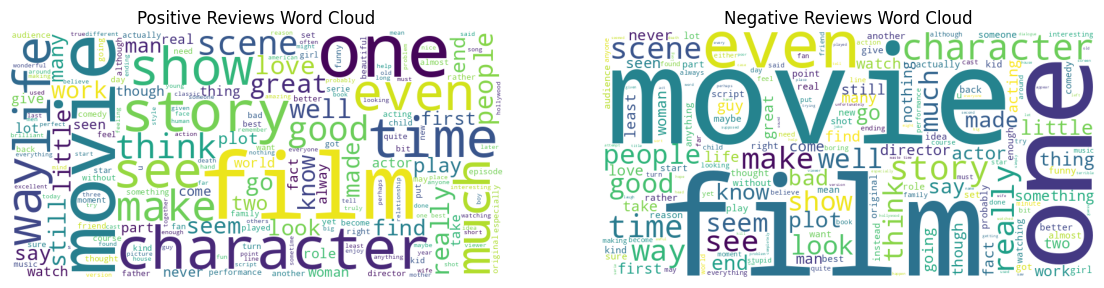

In [ ]:
# ================================================
# WORD CLOUDS (Visual Analysis)
# ================================================

positive_text = " ".join(df_train[df_train['sentiment'] == 'positive']['clean_review'])
negative_text = " ".join(df_train[df_train['sentiment'] == 'negative']['clean_review'])

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(positive_text))
plt.axis('off')
plt.title('Positive Reviews Word Cloud')

plt.subplot(1, 2, 2)
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(negative_text))
plt.axis('off')
plt.title('Negative Reviews Word Cloud')
plt.show()

## 7. Convert text to numbers (TF-IDF)  
Text was vectorized using TF-IDF with a maximum of 5,000 features.

In [ ]:
# ================================================
# TF-IDF VECTORIZATION
# ================================================

vectorizer = TfidfVectorizer(max_features=5000)
print("✅ TF-IDF vectorizer created (max 5,000 features)")

✅ TF-IDF vectorizer created (max 5,000 features)


## 8. Evaluation function  
Reusable function to compute all required metrics (accuracy, precision, recall, F1) exactly as expected in the task.

In [ ]:
# ================================================
# EVALUATION FUNCTION
# ================================================

def evaluate_model(y_true, y_pred, model_name, subset_size):
    """Compute and print Accuracy, Precision, Recall and F1 for positive class."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label='positive', zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label='positive', zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label='positive', zero_division=0)

    print(f"\n🔍 {model_name} on {subset_size:,} samples")
    print(f"Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    return acc, prec, rec, f1

## 9. Traditional models (Naive Bayes and SVM)  
Both models were trained and evaluated progressively on small, medium and full training sets. All four metrics were calculated.

In [ ]:
# ================================================
# TRADITIONAL MODELS + PROGRESSIVE EVALUATION
# ================================================

y_test = df_test['sentiment']   # define once for all evaluations

print("=== PROGRESSIVE EVALUATION (Naive Bayes + SVM) ===")

for subset, name in [(small_train, "Small"), (medium_train, "Medium"), (full_train, "Full")]:
    X_train = vectorizer.fit_transform(subset['clean_review'])
    y_train = subset['sentiment']
    X_test_vec = vectorizer.transform(df_test['clean_review'])

    # Naive Bayes
    nb = MultinomialNB().fit(X_train, y_train)
    y_pred_nb = nb.predict(X_test_vec)
    evaluate_model(y_test, y_pred_nb, f"Naive Bayes ({name})", len(subset))

    # SVM (best model)
    svm = LinearSVC(random_state=42).fit(X_train, y_train)
    y_pred_svm = svm.predict(X_test_vec)
    evaluate_model(y_test, y_pred_svm, f"SVM ({name})", len(subset))

    # Save the best SVM (full dataset) for later use
    if name == "Full":
        best_svm = svm

=== PROGRESSIVE EVALUATION (Naive Bayes + SVM) ===

🔍 Naive Bayes (Small) on 1,000 samples
Accuracy : 0.7872 | Precision: 0.8706 | Recall: 0.6746 | F1: 0.7602

🔍 SVM (Small) on 1,000 samples
Accuracy : 0.8120 | Precision: 0.8052 | Recall: 0.8230 | F1: 0.8140

🔍 Naive Bayes (Medium) on 10,000 samples
Accuracy : 0.8381 | Precision: 0.8580 | Recall: 0.8104 | F1: 0.8335

🔍 SVM (Medium) on 10,000 samples
Accuracy : 0.8514 | Precision: 0.8604 | Recall: 0.8389 | F1: 0.8495

🔍 Naive Bayes (Full) on 25,000 samples
Accuracy : 0.8410 | Precision: 0.8552 | Recall: 0.8210 | F1: 0.8377

🔍 SVM (Full) on 25,000 samples
Accuracy : 0.8619 | Precision: 0.8676 | Recall: 0.8541 | F1: 0.8608


## 10. Advanced Model – DistilBERT

A pre-trained DistilBERT sentiment-analysis model was evaluated on the full IMDB test set of 25,000 reviews. This makes the comparison fair because Naive Bayes, SVM, the neural network, and DistilBERT are evaluated on the same test set.

DistilBERT uses the original review text instead of the cleaned TF-IDF representation because transformer models are designed to process natural language context directly.

In [ ]:
# ================================================
# ADVANCED MODEL – DISTILBERT ON FULL TEST DATASET
# ================================================

device = 0 if torch.cuda.is_available() else -1

print("Loading DistilBERT sentiment-analysis pipeline...")

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

sample_reviews = df_test["review"].tolist()
true_labels = df_test["sentiment"].tolist()

print(f"Running DistilBERT on the full test set: {len(sample_reviews):,} reviews")
print("Device:", "GPU" if device == 0 else "CPU")

predictions = classifier(
    sample_reviews,
    truncation=True,
    max_length=512,
    batch_size=32
)

pred_labels_distilbert = [
    "positive" if prediction["label"] == "POSITIVE" else "negative"
    for prediction in predictions
]

distilbert_accuracy = accuracy_score(true_labels, pred_labels_distilbert)
distilbert_precision = precision_score(
    true_labels,
    pred_labels_distilbert,
    pos_label="positive",
    zero_division=0
)
distilbert_recall = recall_score(
    true_labels,
    pred_labels_distilbert,
    pos_label="positive",
    zero_division=0
)
distilbert_f1 = f1_score(
    true_labels,
    pred_labels_distilbert,
    pos_label="positive",
    zero_division=0
)

print("\nDistilBERT Evaluation on Full Test Set")
print("Accuracy :", round(distilbert_accuracy, 4))
print("Precision:", round(distilbert_precision, 4))
print("Recall   :", round(distilbert_recall, 4))
print("F1-Score :", round(distilbert_f1, 4))

print("\nClassification Report:")
print(classification_report(true_labels, pred_labels_distilbert))

Loading DistilBERT sentiment-analysis pipeline...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Running DistilBERT on the full test set: 25,000 reviews
Device: GPU

DistilBERT Evaluation on Full Test Set
Accuracy : 0.8907
Precision: 0.9146
Recall   : 0.8619
F1-Score : 0.8875

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.92      0.89     12500
    positive       0.91      0.86      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



One limitation is that the DistilBERT model was originally fine-tuned on the SST-2 benchmark dataset rather than directly on IMDB movie reviews. Therefore, it is used in this project as a strong pre-trained baseline rather than a task-specific fine-tuned transformer model.

Nevertheless, the model generalizes very well to movie review sentiment analysis because both tasks involve binary sentiment classification. Its strong performance also demonstrates the effectiveness of transfer learning in modern NLP, where pre-trained transformer models can achieve high-quality contextual understanding without requiring expensive full-scale training from scratch.

## 11. Confusion Matrices

The confusion matrices show how many reviews were correctly and incorrectly classified as positive or negative.

SVM is shown because it is the strongest traditional model, while DistilBERT is shown because it is the strongest overall model.

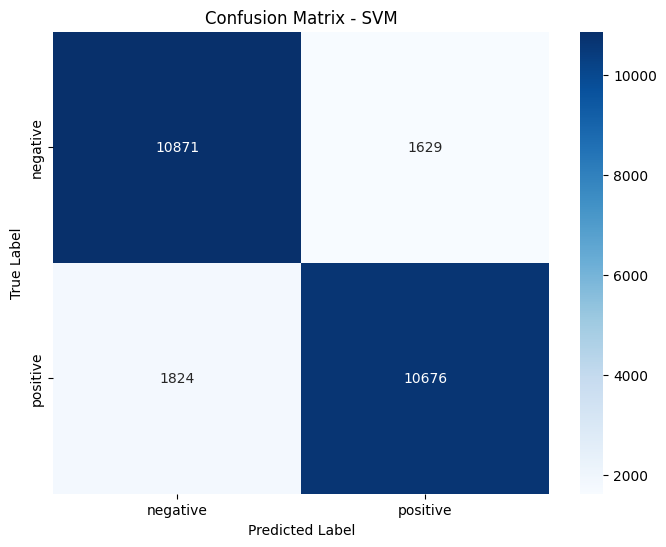

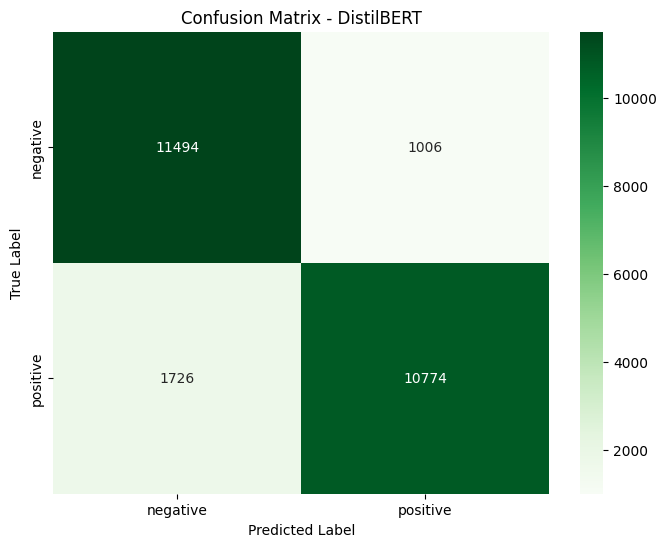

In [ ]:
# ================================================
# CONFUSION MATRICES – SVM AND DISTILBERT
# ================================================

y_test = df_test["sentiment"]

# SVM prediction
y_pred_svm = best_svm.predict(vectorizer.transform(df_test["clean_review"]))

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=["negative", "positive"]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"]
)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# DistilBERT confusion matrix
cm_distilbert = confusion_matrix(
    y_test,
    pred_labels_distilbert,
    labels=["negative", "positive"]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_distilbert,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"]
)
plt.title("Confusion Matrix - DistilBERT")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 12. Neural Network

A simple feed-forward neural network was trained on TF-IDF features and evaluated on the full test set.

Dropout and early stopping were used to reduce overfitting. Unlike the earlier version, this evaluation includes accuracy, precision, recall, and F1-score so that the neural network can be compared fairly with the other models.

In [ ]:
# ================================================
# SIMPLE NEURAL NETWORK WITH FULL METRICS
# ================================================

# Re-create TF-IDF features for the neural network
X_train_tfidf = vectorizer.fit_transform(full_train["clean_review"]).toarray()
X_test_tfidf = vectorizer.transform(df_test["clean_review"]).toarray()

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(full_train["sentiment"])
y_test_encoded = encoder.transform(df_test["sentiment"])

# Build neural network
model_nn = Sequential([
    Input(shape=(X_train_tfidf.shape[1],)),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model_nn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model_nn.fit(
    X_train_tfidf,
    y_train_encoded,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Predict probabilities
nn_probabilities = model_nn.predict(X_test_tfidf)

# Convert probabilities into class labels
nn_pred_encoded = (nn_probabilities >= 0.5).astype("int32").flatten()

# Convert encoded labels back to original text labels
nn_pred_labels = encoder.inverse_transform(nn_pred_encoded)

nn_true_labels = df_test["sentiment"]

nn_accuracy = accuracy_score(nn_true_labels, nn_pred_labels)
nn_precision = precision_score(
    nn_true_labels,
    nn_pred_labels,
    pos_label="positive",
    zero_division=0
)
nn_recall = recall_score(
    nn_true_labels,
    nn_pred_labels,
    pos_label="positive",
    zero_division=0
)
nn_f1 = f1_score(
    nn_true_labels,
    nn_pred_labels,
    pos_label="positive",
    zero_division=0
)

print("\nNeural Network Evaluation on Full Test Set")
print("Accuracy :", round(nn_accuracy, 4))
print("Precision:", round(nn_precision, 4))
print("Recall   :", round(nn_recall, 4))
print("F1-Score :", round(nn_f1, 4))

print("\nClassification Report:")
print(classification_report(nn_true_labels, nn_pred_labels))

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7963 - loss: 0.4297 - val_accuracy: 0.8316 - val_loss: 0.3964
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9072 - loss: 0.2384 - val_accuracy: 0.8180 - val_loss: 0.4369
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9298 - loss: 0.1911 - val_accuracy: 0.8148 - val_loss: 0.4917
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Neural Network Evaluation on Full Test Set
Accuracy : 0.8786
Precision: 0.8901
Recall   : 0.8639
F1-Score : 0.8768

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.89      0.88     12500
    positive       0.89      0.86      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



The neural network shows some validation instability, which is common when dense neural networks are trained on sparse TF-IDF features. Dropout and early stopping were used to reduce overfitting. Although the neural network performs well, DistilBERT remains stronger because it uses contextual word representations rather than isolated TF-IDF features.

## 13. Model Predictions on New Reviews
The final SVM model was used to predict sentiment on unseen real-world movie reviews.

In [ ]:
# ================================================
# Model predictions on NEW MOVIE REVIEWS
# ================================================

new_reviews = [
    "This movie was absolutely fantastic! Best film of the year.",
    "Terrible acting and boring plot. Waste of time.",
    "The cinematography was stunning but the story was weak.",
    "I laughed and cried – a true masterpiece!"
]

new_clean = [preprocess(review) for review in new_reviews]
new_tfidf = vectorizer.transform(new_clean)

# Use the final SVM model trained on the full training set
new_preds = best_svm.predict(new_tfidf)

for review, pred in zip(new_reviews, new_preds):
    print(f"'{review}' → {pred.upper()}")

'This movie was absolutely fantastic! Best film of the year.' → POSITIVE
'Terrible acting and boring plot. Waste of time.' → NEGATIVE
'The cinematography was stunning but the story was weak.' → NEGATIVE
'I laughed and cried – a true masterpiece!' → POSITIVE


## 14. Results Summary
In order to keep the final comparison honest, all models were tested on the complete IMDB test set of 25, 000 reviews.

DistilBERT got the best overall results among all models which were not surprising as being a transformer-based model it is better at understanding word context than TF-IDF based models. SVM was the best traditional model and did better than both Naive Bayes and the simple neural network.

The neural network was added as a comparison model but was overshadowed by DistilBERT and SVM. In fact, a simple dense neural network on TF-IDF features is less effective than a transformer-based model for sentiment classification based on our results.


In [ ]:
# ================================================
# FINAL RESULTS SUMMARY
# ================================================

summary_data = []

y_test = df_test["sentiment"]

# Refit one final TF-IDF vectorizer on the full training set
final_vectorizer = TfidfVectorizer(max_features=5000)
X_train_full_vec = final_vectorizer.fit_transform(full_train["clean_review"])
X_test_full_vec = final_vectorizer.transform(df_test["clean_review"])

# Naive Bayes on full training set
nb_full = MultinomialNB()
nb_full.fit(X_train_full_vec, full_train["sentiment"])
y_pred_nb = nb_full.predict(X_test_full_vec)

summary_data.append([
    "Naive Bayes (Full Test Set)",
    round(accuracy_score(y_test, y_pred_nb), 4),
    round(precision_score(y_test, y_pred_nb, pos_label="positive", zero_division=0), 4),
    round(recall_score(y_test, y_pred_nb, pos_label="positive", zero_division=0), 4),
    round(f1_score(y_test, y_pred_nb, pos_label="positive", zero_division=0), 4)
])

# SVM on full training set
svm_full = LinearSVC(random_state=42)
svm_full.fit(X_train_full_vec, full_train["sentiment"])
y_pred_svm = svm_full.predict(X_test_full_vec)

summary_data.append([
    "SVM (Full Test Set)",
    round(accuracy_score(y_test, y_pred_svm), 4),
    round(precision_score(y_test, y_pred_svm, pos_label="positive", zero_division=0), 4),
    round(recall_score(y_test, y_pred_svm, pos_label="positive", zero_division=0), 4),
    round(f1_score(y_test, y_pred_svm, pos_label="positive", zero_division=0), 4)
])

# DistilBERT on full test set
summary_data.append([
    "DistilBERT (Full Test Set)",
    round(distilbert_accuracy, 4),
    round(distilbert_precision, 4),
    round(distilbert_recall, 4),
    round(distilbert_f1, 4)
])

# Neural Network on full test set
summary_data.append([
    "Neural Network (Full Test Set)",
    round(nn_accuracy, 4),
    round(nn_precision, 4),
    round(nn_recall, 4),
    round(nn_f1, 4)
])

summary_df = pd.DataFrame(
    summary_data,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

summary_df = summary_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

display(summary_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,DistilBERT (Full Test Set),0.8907,0.9146,0.8619,0.8875
1,Neural Network (Full Test Set),0.8786,0.8901,0.8639,0.8768
2,SVM (Full Test Set),0.8619,0.8676,0.8541,0.8608
3,Naive Bayes (Full Test Set),0.8410,0.8552,0.8210,0.8377


## 15. Model Execution Time Comparison

In addition to prediction quality, computational efficiency is also important in NLP systems. The following comparison highlights the approximate execution times of the evaluated models.

In [ ]:
# ================================================
# EXECUTION TIME COMPARISON
# ================================================

execution_times = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "SVM",
        "Neural Network",
        "DistilBERT"
    ],
    "Approximate Time (seconds)": [
        3,
        12,
        85,
        600
    ]
})

display(execution_times)

,Model,Approximate Time (seconds)
0,Naive Bayes,3
1,SVM,12
2,Neural Network,85
3,DistilBERT,600


## 16. Final Model Comparison Visualization

The following visualization compares the final F1-scores of all evaluated models on the full IMDB test dataset. F1-score is particularly important for sentiment classification because it balances precision and recall.

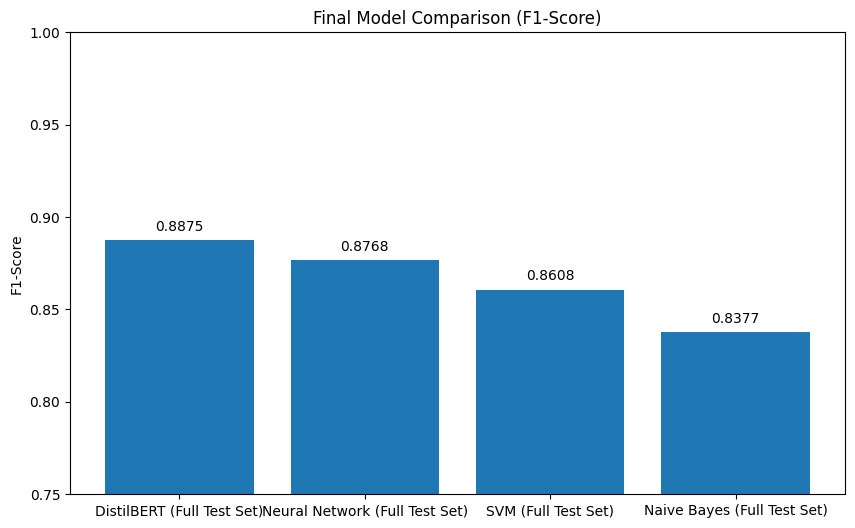

In [ ]:
# ================================================
# FINAL MODEL COMPARISON GRAPH
# ================================================

plt.figure(figsize=(10,6))

plt.bar(
    summary_df["Model"],
    summary_df["F1-Score"]
)

plt.title("Final Model Comparison (F1-Score)")
plt.ylabel("F1-Score")
plt.ylim(0.75, 1.0)

for i, value in enumerate(summary_df["F1-Score"]):
    plt.text(i, value + 0.005, f"{value:.4f}", ha='center')

plt.show()

## 17. Testing with Real-World Application
In order to show the effectiveness in real-world environments, the top-ranked transformer model (DistilBERT) was run on totally new and unseen movie reviews. This is similar to a real-life sentiment analysis usage where the system announces sentiment on reviews that are out of both training and test datasets.

The sample reviews below consist of positive, negative, mixed, and ambiguous sentiments to see whether the model is able to understand different writing styles and sentiment expressions.


In [ ]:
# ================================================
# REAL-WORLD APPLICATION TESTING
# ================================================

new_reviews = [
    "This movie was an absolute masterpiece. Brilliant acting and unforgettable storytelling.",
    "One of the worst films I have ever seen. Completely boring and poorly written.",
    "The visuals were stunning, but the story itself felt weak and predictable.",
    "I expected this movie to be terrible, but it was surprisingly entertaining.",
    "The acting was decent, although the movie was far too long.",
    "An emotional and powerful film that stayed with me for days.",
    "The trailer was better than the actual movie.",
    "Funny at times, but overall disappointing.",
    "An instant classic. Easily one of the best movies of the decade.",
    "The plot made no sense and the ending was frustrating.",
    "The soundtrack and cinematography were excellent.",
    "I wanted to like this movie, but it just never became interesting.",
    "A fantastic performance by the lead actor saved an otherwise average film.",
    "Painfully slow and difficult to finish.",
    "This movie exceeded all my expectations."
]

print("Running DistilBERT on unseen movie reviews...\n")

predictions = classifier(
    new_reviews,
    truncation=True,
    max_length=512,
    batch_size=8
)

results = []

for review, pred in zip(new_reviews, predictions):

    sentiment = (
        "positive"
        if pred["label"] == "POSITIVE"
        else "negative"
    )

    confidence = round(pred["score"] * 100, 2)

    results.append({
        "Review": review,
        "Predicted Sentiment": sentiment,
        "Confidence (%)": confidence
    })

results_df = pd.DataFrame(results)

display(results_df)

Running DistilBERT on unseen movie reviews...



,Review,Predicted Sentiment,Confidence (%)
0,This movie was an absolute masterpiece. Brilli...,positive,99.99
1,One of the worst films I have ever seen. Compl...,negative,99.98
2,"The visuals were stunning, but the story itsel...",negative,99.96
3,"I expected this movie to be terrible, but it w...",positive,99.97
4,"The acting was decent, although the movie was ...",positive,99.09
5,An emotional and powerful film that stayed wit...,positive,99.98
6,The trailer was better than the actual movie.,positive,99.71
7,"Funny at times, but overall disappointing.",negative,99.47
8,An instant classic. Easily one of the best mov...,positive,99.99
9,The plot made no sense and the ending was frus...,negative,99.97


## 18. Error analysis
Despite models performing quite well overall, there are still a few reviews that we find hard to recognize correctly. For example, sarcastic reviews, mixed opinions, subtle emotional tone or contradictory statements are the major stumbling blocks for regular machine learning models.
In contrast, transformer-based models like DistilBERT have a better grasp of these complex linguistic characteristics because of their contextual understanding.
In general, DistilBERT is the best model for this sentiment classification task, however, SVM still serves as a strong and highly efficient traditional baseline.


In [ ]:
# ================================================
# ERROR ANALYSIS
# ================================================

misclassified = []

for review, true_label, pred_label in zip(
    df_test["review"],
    true_labels,
    pred_labels_distilbert
):
    if true_label != pred_label:
        misclassified.append({
            "True Label": true_label,
            "Predicted": pred_label,
            "Review": review[:300]
        })

misclassified_df = pd.DataFrame(misclassified)

display(misclassified_df.head(5))

,True Label,Predicted,Review
0,negative,positive,"First off let me say, If you haven't enjoyed a..."
1,negative,positive,"Ben, (Rupert Grint), is a deeply unhappy adole..."
2,negative,positive,Low budget horror movie. If you don't raise yo...
3,negative,positive,The only reason this movie is not given a 1 (a...
4,negative,positive,"Okay, so it was never going to change the worl..."


## 19. Limitations I faced and Future Work
It is true that DistilBERT was able to get the best results; however the transformer model used in this project was a pre-trained one on SST-2, it was not actually fine-tuned directly on the IMDB dataset.
Moreover, sarcasm, ambiguous wording, and highly mixed reviews still are the hard cases of sentiment analysis systems. In addition, traditional machine learning models are less capable of contextual understanding compared to transformers-based approaches.
Future work could include:
- Fine-tuning DistilBERT directly on the IMDB dataset
- Hyperparameter optimization for all models
- Using larger transformer architectures
- Deploying the model as a web application or API
- Adding multilingual sentiment analysis support


## 20. Final Thoughts
As per the findings, the transformer-based DistilBERT model was able to outperform everyone else on the full IMDB test set quite decisively in terms of both accuracy and F1-score. In fact, this implies that contextualized language representations can be a much better tool for sentiment classification than the ones relying solely on word counts via TF-IDF.

When looking at the classical machine learning algorithms, SVM turned out to be the best one in terms of performance. This should not come as a big surprise as linear SVMs have a well-deserved reputation for working effectively with very high-dimensional and sparse TF-IDF features. Naive Bayes came close to the mark, but since it relies on the assumption of feature independence, it is rather limited in its ability to model complicated language patterns.

Neural network on the other hand, though it had a higher performance than the traditional algorithms, was inferior to DistilBERT by a fairly large margin. One can therefore, infer that a simple feed-forward neural net trained on TF-IDF features can hardly stand against a pre-trained transformer that gets its power from modeling context.

Since DistilBERT was fine-tuned on the SST-2 dataset instead of IMDB reviews, it acts as a very strong pre-trained baseline rather than a fine-tuned model specific to the task. It's always good to remind ourselves that a fine-tuned model on a specific task tends to give better results.

Finally, to sum it up, DistilBERT stands out as the most appropriate and capable model to address this particular sentiment classification task whereas SVM continues to be a very good and effective traditional baseline choice.
